<a href="https://colab.research.google.com/github/binghan1123/1142-programming-language/blob/main/HW1_%E6%97%A5%E5%B8%B8%E6%94%AF%E5%87%BA%E9%80%9F%E7%AE%97%E8%88%87%E5%88%86%E6%94%A4_%E6%9C%80%E7%B5%82%E7%89%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#日常支出速算與分攤（作業一）
- 目標：從 Sheet 讀「消費紀錄」→ 計總額/分類小計/AA 分攤 → 寫回 Sheet Summary 分頁。
- AI 點子（可選）：請模型總結本週花錢習慣與建議（例如「外食過多」）。
- Sheet 欄位：date, category, item, amount, payer

GoogleSheet: https://docs.google.com/spreadsheets/d/1yefD7L8LSK27T-B_V4PWyk6tEUl5IGUCs9Lw8SbCGF0/edit?usp=sharing

### 確保中文字體顯示正常
為了在圖表中正確顯示中文，我們需要安裝一個中文字體並設定 Matplotlib 使用它。

In [18]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# Define the expected font file path after installing fonts-wqy-zenhei
wqy_zenhei_font_path = '/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc'
actual_chinese_font_family_name = None

# Check if the font file exists. If not, try to install the package.
if not os.path.exists(wqy_zenhei_font_path):
    print(f"Font file '{wqy_zenhei_font_path}' not found. Attempting to install 'fonts-wqy-zenhei'...")
    !apt-get update -qq > /dev/null
    !apt-get install -y fonts-wqy-zenhei > /dev/null
    # Clear and reload font cache to ensure newly installed fonts are recognized
    fm._load_fontmanager(try_read_cache=False)
    print("Font package installed and font cache reloaded.")

# After potential installation, try to add the font to Matplotlib's manager
if os.path.exists(wqy_zenhei_font_path):
    # Add the font file to Matplotlib's font manager
    fm.fontManager.addfont(wqy_zenhei_font_path)
    # Get the actual font family name from the font properties
    prop = fm.FontProperties(fname=wqy_zenhei_font_path)
    actual_chinese_font_family_name = prop.get_name()
    print(f"Registered Matplotlib font family name: '{actual_chinese_font_family_name}'")

    # Set Matplotlib to use this font family
    plt.rcParams['font.sans-serif'] = [actual_chinese_font_family_name, 'DejaVu Sans', 'sans-serif']
    plt.rcParams['axes.unicode_minus'] = False   # Resolve minus sign display issues
    print("Matplotlib 中文字體設定完成。")
else:
    print(f"WARNING: Font file '{wqy_zenhei_font_path}' still not found after installation attempts. Plots might not display Chinese characters correctly.")
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'sans-serif'] # Fallback
    plt.rcParams['axes.unicode_minus'] = False
    print("Matplotlib 中文字體設定失敗，將使用預設字體。")

Registered Matplotlib font family name: 'WenQuanYi Zen Hei'
Matplotlib 中文字體設定完成。


In [20]:
import gradio as gr
import pandas as pd
import datetime
import gspread
from google.colab import auth
from google.auth import default

In [21]:
from google.colab import auth
import gspread
from google.auth import default

# 執行此單元格後，請點擊連結或在彈出視窗中完成驗證
try:
    auth.authenticate_user()
    creds, _ = default()
    gc = gspread.authorize(creds)
    print("驗證成功！")
except Exception as e:
    print(f"驗證失敗，請檢查瀏覽器是否封鎖了彈出視窗。錯誤訊息: {e}")

驗證成功！


In [22]:
SHEET_URL = "https://docs.google.com/spreadsheets/d/1yefD7L8LSK27T-B_V4PWyk6tEUl5IGUCs9Lw8SbCGF0/edit?usp=sharing"
WORKSHEET_NAME = "工作表1"

REQUIRED_COLUMNS = ["日期", "時間", "分類", "品項", "單價", "數量", "總金額", "付款人", "地點", "支付方式", "備註"]

_auth_done = False
_gc = None
_ws = None

In [23]:
#def add_expense(date_str, time_str, category, item, amount, payer):

In [24]:
def _ensure_headers():
    """確保表頭包含 REQUIRED_COLUMNS；若空表或缺欄，會補齊。"""
    rows = _ws.get_all_values()
    if not rows:
        _ws.append_row(REQUIRED_COLUMNS, value_input_option="USER_ENTERED")
        return
    header = rows[0]
    print(f"目前的標頭欄位為: {header}")
    if header != REQUIRED_COLUMNS:
        # 合併既有欄與必需欄，並以 REQUIRED_COLUMNS 為主順序
        existing = {h: idx for idx, h in enumerate(header)}
        # 若第一列不是必需欄，重寫表頭並搬移資料欄位（簡化處理：補欄位）
        _ws.update('1:1', [REQUIRED_COLUMNS])

        # 若舊資料有相同欄位名，保留；沒有的欄位留空
        if len(rows) > 1:
            new_rows = []
            for r in rows[1:]:
                mapping = {col: (r[existing[col]] if col in existing and existing[col] < len(r) else "")
                           for col in REQUIRED_COLUMNS}
                new_rows.append([mapping[c] for c in REQUIRED_COLUMNS])
            # 先清掉舊內容只留表頭
            _ws.resize(rows=1)
            # 再補回資料
            _ws.append_rows(new_rows, value_input_option="USER_ENTERED")

In [25]:
import datetime

In [26]:
def _ensure_auth_and_ws():
    global _auth_done, _gc, _ws
    if not _auth_done:
        # Colab 使用者授權
        auth.authenticate_user()
        creds, _ = default()
        _gc = gspread.authorize(creds)
        _auth_done = True
    if _ws is None:
        gs = _gc.open_by_url(SHEET_URL)
        _ws = gs.worksheet(WORKSHEET_NAME)
        # 確保欄位完整
        _ensure_headers()
    return _ws

In [27]:
sheets = _ensure_auth_and_ws().get_all_values()
df = pd.DataFrame(sheets[1:], columns=sheets[0])
df

目前的標頭欄位為: ['日期', '時間', '分類', '品項', '單價', '數量', '總金額', '付款人', '地點', '支付方式', '備註']


,日期,時間,分類,品項,單價,數量,總金額,付款人,地點,支付方式,備註
0,2026-03-05,9:05,股票,50,78.5,84,6594,熊本熊本熊,,,
1,2026-03-05,9:05,股票,50,78.5,84,6594,熊本熊本熊,,,
2,2026-03-05,9:05,股票,50,78.5,84,6594,熊本熊本熊,,,
3,2026-03-05,9:08,股票,50,78.5,84,6594,熊本熊本熊,股市,交割戶扣款,手續費20
4,2026-03-05,9:08,股票,50,78.5,84,6594,熊本熊本熊,股市,交割戶扣款,手續費20
5,2026-03-05,9:10,股票,50,78.5,84,6594,熊本熊本熊,股市,交割戶扣款,手續費20
6,2026-03-05,9:05,股票,50,78.5,84,6594,熊本熊本熊,,,
7,2026-03-05,9:05,股票,50,78.5,84,6594,熊本熊本熊,,,
8,2026-03-05,9:05,股票,50,78.5,84,6594,熊本熊本熊,,,
9,2026-03-05,9:08,股票,50,78.5,84,6594,熊本熊本熊,股市,交割戶扣款,手續費20


In [28]:
import datetime

def add_expense(date_str, time_str, category, item, unit_price, quantity, total_amount, payer, location, payment_method, note):
    try:
        # 1. 處理日期與時間（基本驗證）
        if not date_str:
            date_str = datetime.date.today().strftime("%Y-%m-%d")
        if time_str:
            datetime.datetime.strptime(time_str, "%H:%M") # 檢查時間格式是否正確

        # 2. 處理文字欄位（設定預設值並去除頭尾空白）
        category = (category or "未填").strip()
        item = (item or "未填").strip()
        payer = (payer or "匿名").strip()
        location = (location or "").strip()          # 地點允許空白
        payment_method = (payment_method or "現金").strip() # 預設現金
        note = (note or "").strip()                  # 備註允許空白

        # 3. 處理數字欄位（單價、數量、總金額）
        try:
            unit_price_val = float(unit_price) if unit_price else 0.0
            quantity_val = float(quantity) if quantity else 1.0 # 預設數量為 1

            # 如果沒有手動輸入總金額，系統自動用 單價 * 數量 計算
            if total_amount:
                total_amount_val = float(total_amount)
            else:
                total_amount_val = unit_price_val * quantity_val

        except ValueError:
            return "❌ 單價、數量或總金額格式錯誤，請確保輸入的是數字", None, None, None

        # 4. 確保試算表連線並寫入資料
        ws = _ensure_auth_and_ws()

        # 💡 這裡的順序必須跟 REQUIRED_COLUMNS 一模一樣
        new_row = [
            date_str,
            time_str or "",
            category,
            item,
            unit_price_val,
            quantity_val,
            total_amount_val,
            payer,
            location,
            payment_method,
            note
        ]

        ws.append_row(new_row, value_input_option="USER_ENTERED")

        msg = f"✅ 已新增：{date_str}｜{category}｜{item}｜總計 {total_amount_val} 元"

        # 5. 重新讀取 DataFrame 並更新即時摘要
        df = _read_df()
        cat, settle = _make_summary_tables(df)

        # 💡 注意這裡！改成讀取 "總金額" 欄位，因為 REQUIRED_COLUMNS 是叫總金額
        total = float(df["總金額"].sum()) if not df.empty else 0.0

        return msg, total, cat, settle

    except Exception as e:
        return f"❌ 新增失敗：{e}", None, None, None

In [29]:
import pandas as pd

def _read_df():
    ws = _ensure_auth_and_ws()
    values = ws.get_all_values()
    if not values:
        # 如果是空表，回傳帶有正確 11 個欄位的空 DataFrame
        return pd.DataFrame(columns=REQUIRED_COLUMNS)

    df = pd.DataFrame(values[1:], columns=values[0])

    # 型別整理：將與數字有關的欄位轉換為數值，若輸入有誤則強制作為 0.0
    for col in ["單價", "數量", "總金額"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)

    return df

def refresh_summary():
    try:
        df = _read_df()
        if df.empty:
            return "目前沒有資料", 0.0, pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

        # 修正：將 "金額" 改為 "總金額"
        total = float(df["總金額"].sum())
        by_cat, settle = _make_summary_tables(df)

        return "✅ 已更新彙總", total, by_cat, settle, df
    except Exception as e:
        return f"❌ 讀取失敗：{e}", 0.0, pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

def _make_summary_tables(df: pd.DataFrame):
    # 1. 分類小計
    if "分類" in df.columns and "總金額" in df.columns:
        # 修正：依照 "總金額" 進行群組加總與排序
        by_cat = df.groupby("分類", as_index=False)["總金額"].sum().sort_values("總金額", ascending=False)
    else:
        # 修正：預設欄位名稱改為 "總金額"
        by_cat = pd.DataFrame(columns=["分類", "總金額"])

    # 2. 付款人結算（AA 分攤）
    if "付款人" in df.columns and df["付款人"].notna().any():
        payers = df["付款人"].replace("", "匿名")

        # 找出所有不重複的付款人（過濾掉空白）
        unique_payers = sorted([p for p in payers.unique() if p])

        # 修正：總金額加總
        total = df["總金額"].sum()
        n = max(len(unique_payers), 1) # 避免除以 0
        aa_share = total / n # 計算每人平均應付金額

        # 修正：依付款人加總 "總金額"，並改名為 "實付"
        paid_by = df.groupby("付款人", as_index=False)["總金額"].sum().rename(columns={"總金額": "實付"})

        # 確保每位付款人都有列（包含幫忙出錢但沒記在自己名下的人）
        all_rows = pd.DataFrame({"付款人": unique_payers}).merge(paid_by, on="付款人", how="left").fillna({"實付": 0.0})
        all_rows["應付(AA)"] = aa_share
        all_rows["差額(實付-應付)"] = all_rows["實付"] - all_rows["應付(AA)"]

        settle = all_rows.sort_values("差額(實付-應付)", ascending=False)
    else:
        settle = pd.DataFrame(columns=["付款人", "實付", "應付(AA)", "差額(實付-應付)"])

    return by_cat, settle

In [30]:
with gr.Blocks(title="日常支出速算與分攤", theme=gr.themes.Soft()) as demo:
    gr.Markdown("## 🧾 日常支出速算與分攤（Gradio）\n- 新增支出後自動寫回 Google Sheet\n- 一鍵查看總額、分類小計與 AA 分攤\n- 包含單價、數量自動計算總金額功能")

    with gr.Tab("➕ 新增支出"):
        # 第一排：時間資訊
        with gr.Row():
            date_in = gr.Textbox(label="日期 YYYY-MM-DD", value=datetime.date.today().strftime("%Y-%m-%d"))
            time_in = gr.Textbox(label="時間 HH:MM（可留白）", value="")

        # 第二排：基本資訊
        with gr.Row():
            cat_in = gr.Textbox(label="分類", placeholder="如 外食 / 交通 / 購物")
            item_in = gr.Textbox(label="品項", placeholder="如 咖啡 / 便當 / 車票")
            location_in = gr.Textbox(label="地點（可留白）", placeholder="如 7-11 / 台北車站")

        # 第三排：金額計算
        with gr.Row():
            unit_price_in = gr.Textbox(label="單價", placeholder="輸入數字")
            qty_in = gr.Textbox(label="數量", value="1", placeholder="預設為 1")
            total_amt_in = gr.Textbox(label="總金額（可留白）", placeholder="留白則自動用 單價×數量 計算")

        # 第四排：付款與備註
        with gr.Row():
            payer_in = gr.Textbox(label="付款人", placeholder="如 Pecu / Alice / Bob")
            pay_method_in = gr.Textbox(label="支付方式", value="現金", placeholder="如 現金 / 信用卡 / LinePay")
            note_in = gr.Textbox(label="備註（可留白）", placeholder="其他想記錄的事")

        add_btn = gr.Button("新增到工作表", variant="primary")

        # 新增結果的顯示區塊
        add_msg = gr.Markdown()
        total_out = gr.Number(label="目前總額", interactive=False)
        with gr.Row():
            cat_df = gr.Dataframe(label="分類小計", interactive=False)
            settle_df = gr.Dataframe(label="AA 分攤結算", interactive=False)

        # 💡 將 11 個輸入框與 add_expense 函式綁定 (順序必須一致)
        add_btn.click(
            fn=add_expense,
            inputs=[
                date_in, time_in, cat_in, item_in,
                unit_price_in, qty_in, total_amt_in,
                payer_in, location_in, pay_method_in, note_in
            ],
            outputs=[add_msg, total_out, cat_df, settle_df]
        )

    with gr.Tab("📊 彙總 / AA 分攤"):
        refresh_btn = gr.Button("讀取最新彙總", variant="primary")
        msg2 = gr.Markdown()
        total2 = gr.Number(label="總額", interactive=False)
        with gr.Row():
            cat_df2 = gr.Dataframe(label="分類小計", interactive=False)
            settle_df2 = gr.Dataframe(label="AA 分攤結算", interactive=False)
        raw_preview = gr.Dataframe(label="（預覽）最近資料", interactive=False)

        refresh_btn.click(
            fn=refresh_summary,
            inputs=[],
            outputs=[msg2, total2, cat_df2, settle_df2, raw_preview]
        )

    with gr.Tab("📒 檢視原始資料"):
        view_btn = gr.Button("讀取資料", variant="primary")
        view_df = gr.Dataframe(label="全部資料", interactive=False)

        def _view_all():
            try:
                # 使用我們之前改好的 _read_df，確保讀出來的格式是對的
                df = _read_df()
                if df.empty:
                    # 如果沒資料，顯示 11 個欄位的空表格
                    return pd.DataFrame(columns=REQUIRED_COLUMNS)
                return df
            except Exception as e:
                return pd.DataFrame({"錯誤": [str(e)]})

        view_btn.click(fn=_view_all, inputs=[], outputs=[view_df])

# 啟動介面
demo.launch(share=True)

/tmp/ipykernel_5021/960654887.py:1: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title="日常支出速算與分攤", theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a383e5ae86f1ba9a8d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


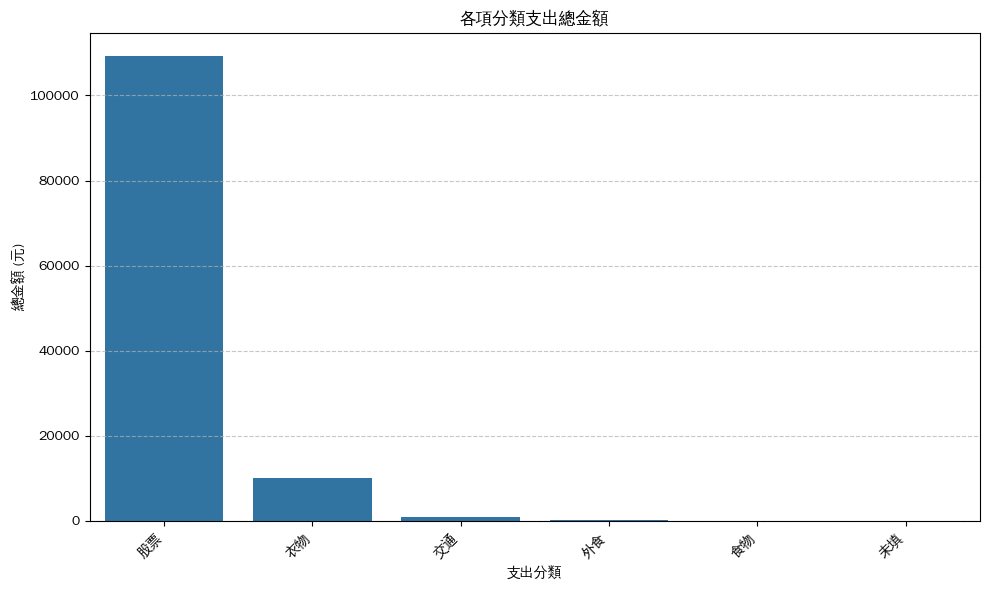

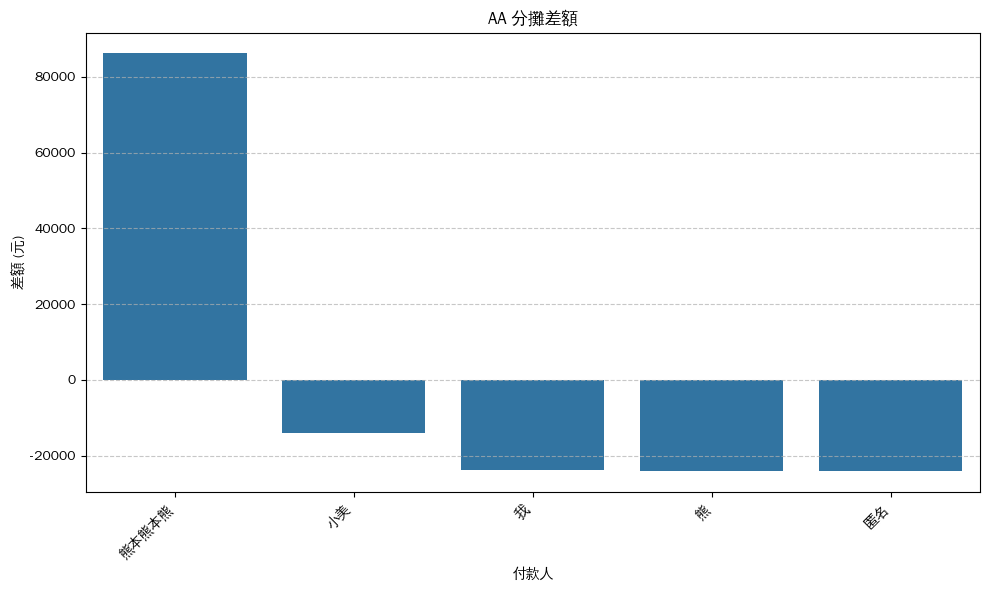

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# 確保 df 和 by_cat 是最新的
message, total, by_cat, settle, full_df = refresh_summary()

if not by_cat.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x='分類', y='總金額', data=by_cat)
    plt.title('各項分類支出總金額')
    plt.xlabel('支出分類')
    plt.ylabel('總金額 (元)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("沒有分類小計資料可供繪製圖表。")

if not settle.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x='付款人', y='差額(實付-應付)', data=settle)
    plt.title('AA 分攤差額')
    plt.xlabel('付款人')
    plt.ylabel('差額 (元)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("沒有 AA 分攤結算資料可供繪製圖表。")

### 消費習慣分析與建議
根據您的消費紀錄，我將為您總結消費習慣並提供一些建議。

In [33]:
# 確保數據是最新的
message, total, by_cat, settle, full_df = refresh_summary()

summary_text = []
recommendations = []

summary_text.append(f"**您的總消費金額為：{total:.2f} 元。**\n")

if not by_cat.empty:
    summary_text.append("**消費分類分佈：**\n")
    for index, row in by_cat.iterrows():
        summary_text.append(f"- {row['分類']}: {row['總金額']:.2f} 元")
    summary_text.append("\n")

    # 找出花費最高的類別
    most_spent_category = by_cat.iloc[0]['分類']
    most_spent_amount = by_cat.iloc[0]['總金額']
    if most_spent_category == '股票':
        recommendations.append("**投資方面**：您在股票上的花費較高，這可能是投資。請確保您的投資策略穩健，並定期檢視投資組合風險。")
    elif most_spent_category == '外食':
        recommendations.append("**飲食方面**：外食費用佔比很高。考慮偶爾在家開伙，不僅能節省開支，也能更健康。")
    elif most_spent_category == '交通':
        recommendations.append("**交通方面**：交通支出較多。檢視是否有更經濟實惠的通勤方式，例如使用大眾運輸、騎自行車或拼車。")
    elif most_spent_category == '衣物':
        # FIX: Changed inner double quotes to single quotes
        recommendations.append("**購物方面**：衣物支出佔比高。建議在購買前多加考慮是否真的需要，可以嘗試'30天規則'（等待30天再決定是否購買）。")
    elif most_spent_category == '食物':
        recommendations.append("**飲食方面**：食物支出較高。建議可以開始記錄每天的飲食，看看是不是有無形中多花了錢的習慣。")
    else:
        recommendations.append(f"**在'{most_spent_category}'類別的花費較高**：建議檢視此類別的開支，看是否有優化的空間。")

if not settle.empty and len(settle['付款人'].unique()) > 1: # 只有多於一人才做AA分攤建議
    summary_text.append("**AA 分攤狀況：**\n")
    for index, row in settle.iterrows():
        summary_text.append(f"- {row['付款人']} 實付：{row['實付']:.2f} 元，應付(AA)：{row['應付(AA)']:.2f} 元，差額：{row['差額(實付-應付)']:.2f} 元")
    summary_text.append("\n")

    # 找出差額最大的付款人
    largest_difference_payer = settle.loc[settle['差額(實付-應付)'].idxmax()]
    if largest_difference_payer['差額(實付-應付)'] > 0:
        recommendations.append(f"**付款人結算**：'{largest_difference_payer['付款人']}'支付的金額遠超應付金額，可能需要提醒其他人結算或重新分配共同支出。")

    smallest_difference_payer = settle.loc[settle['差額(實付-應付)'].idxmin()]
    if smallest_difference_payer['差額(實付-應付)'] < 0:
        recommendations.append(f"**付款人結算**：'{smallest_difference_payer['付款人']}'支付的金額遠低於應付金額，可能需要補足差額。")

if not full_df.empty:
    # 簡單的時間趨勢分析（如果日期數據足夠）
    # 需要將 '日期' 轉換為日期時間格式
    full_df['日期'] = pd.to_datetime(full_df['日期'], errors='coerce')
    # 移除無效日期
    full_df_valid_dates = full_df.dropna(subset=['日期'])

    if not full_df_valid_dates.empty and full_df_valid_dates['日期'].nunique() > 1:
        # 找出最近的消費日期
        latest_date = full_df_valid_dates['日期'].max().strftime('%Y-%m-%d')
        summary_text.append(f"您最近一筆消費紀錄日期是：{latest_date}\n")

# 如果沒有任何消費紀錄，提供基本建議
if total == 0:
    summary_text = ["目前沒有任何消費紀錄。請開始記錄您的支出，以便我們為您分析消費習慣。"]
    recommendations = ["**開始記錄**：堅持記錄每一筆支出，這是理財的第一步。"]

print("\n".join(summary_text))
print("\n**個人化建議：**\n")
if recommendations:
    for rec in recommendations:
        print(f"- {rec}")
else:
    print("目前沒有特定的個人化建議，請持續記錄更多數據以獲得更精準的分析。")

**您的總消費金額為：120632.00 元。**

**消費分類分佈：**

- 股票: 109302.00 元
- 衣物: 10000.00 元
- 交通: 1000.00 元
- 外食: 280.00 元
- 食物: 50.00 元
- 未填: 0.00 元


**AA 分攤狀況：**

- 熊本熊本熊 實付：110302.00 元，應付(AA)：24126.40 元，差額：86175.60 元
- 小美 實付：10000.00 元，應付(AA)：24126.40 元，差額：-14126.40 元
- 我 實付：280.00 元，應付(AA)：24126.40 元，差額：-23846.40 元
- 熊 實付：50.00 元，應付(AA)：24126.40 元，差額：-24076.40 元
- 匿名 實付：0.00 元，應付(AA)：24126.40 元，差額：-24126.40 元


您最近一筆消費紀錄日期是：2026-03-19


**個人化建議：**

- **投資方面**：您在股票上的花費較高，這可能是投資。請確保您的投資策略穩健，並定期檢視投資組合風險。
- **付款人結算**：'熊本熊本熊'支付的金額遠超應付金額，可能需要提醒其他人結算或重新分配共同支出。
- **付款人結算**：'匿名'支付的金額遠低於應付金額，可能需要補足差額。
